# M1M9：Out-of-time cross-fit + Adaptive residual window EnbPI

這份 notebook 不會覆蓋原本的 `KF_m1m9_EnbPI.ipynb`。主要差異是：ARIMA+ANN 兩個分支被視為一個完整 predictor，在 training period 內做 expanding-window、future-block cross-fitting，取得真正 out-of-time 的 calibration residuals；residual window 長度 W 只使用 training residuals 的 prequential interval score 選擇。Testing 開始後固定 W，收到每一期真值後才更新 residual pool。

區間仍使用原 EnbPI 的 shortest residual interval，不使用 equal-tail interval。

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

meeting_root = None
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / 'src' / 'kf_forecasting').exists():
        meeting_root = candidate
        break
if meeting_root is None:
    raise RuntimeError('找不到 meeting/src/kf_forecasting，請從 project/meeting 或其子目錄啟動 notebook。')
sys.path.insert(0, str(meeting_root / 'src'))

from kf_forecasting.models.kf_enbpi import EnbPIConfig, plot_result
from kf_forecasting.models.kf_out_of_time_enbpi import (
    OutOfTimeEnbPIConfig,
    monte_carlo_out_of_time,
    plot_window_selection,
    simulate_and_run_out_of_time,
)


## 設定

`initial_train_fraction=0.5` 表示前 50% training observations 只用來建立第一個模型，後 50% 被切成 4 個連續 future blocks。每個 block 開始前重新用當時所有過去資料做 ARIMA order selection、ANN rolling validation 與 B 組 bootstrap fitting。`residual_window_candidates` 中的 `None` 代表保留所有已取得的 calibration residuals。

In [3]:
base_config = EnbPIConfig(
    window_size=15,
    alpha=0.05,
    n_bootstrap=30,
    block_length=None,
    batch_size=1,
    beta_grid_size=101,
    oob_bias_correction=True,
    oob_bias_correction_mode='combined',
    arima_order=None,
    arima_max_p=4,
    arima_max_q=4,
    arima_max_iter=500,
    ann_hidden_layers=(32, 16),
    ann_max_iter=500,
    ann_alpha=1e-4,
    ann_learning_rate_init=1e-3,
    ann_target_standardization=True,
    ann_early_stopping=False,
    ann_rolling_validation=True,
    ann_rolling_splits=3,
    ann_validation_fraction=0.10,
    ann_iteration_candidates=(125, 250, 500),
    ann_tol=1e-3,
    random_state=1234,
)

config = OutOfTimeEnbPIConfig(
    base=base_config,
    initial_train_fraction=0.50,
    n_crossfit_blocks=4,
    residual_window_candidates=(100, 200, 300, 400, None),
    window_validation_fraction=0.40,
    min_window_history=40,
)

train_size = 650
horizon = 200
data_seed = 2026


## 單次實驗

In [4]:
out_of_time_result = simulate_and_run_out_of_time(
    'm1m9',
    train_size=train_size,
    horizon=horizon,
    config=config,
    data_seed=data_seed,
)
result = out_of_time_result.forecast

final_summary, component_summary, calibration_summary = out_of_time_result.summary_tables()
display(final_summary)
display(component_summary)
display(calibration_summary)


,model,data_seed,ensemble_seed,arima_order,mse,rmse,coverage_percent,mean_width,mean_beta,mean_bias_correction,bias_correction_mode,ann_selected_max_iter_mean,ann_rolling_validation_mse,ann_nonconverged_models,arima_retry_count,arima_nonconverged_fits,elapsed_seconds
0,M1M9,2026,1234,"(2, 0, 0)",3.508072,1.872985,95.0,7.130668,0.031977,-0.42821,combined,125.0,3.399878,30,0,0,190.455089


,component,reference,mse,rmse,coverage_percent,enbpi_mean_width,mean_beta,mean_bias_correction
0,low_arima,kalman_low,0.198950,0.446038,93.5,1.713373,0.033192,0.0
1,high_ann_mse,kalman_high,2.310120,1.519908,95.5,5.563521,0.031360,0.0
2,low_arima,true_low,5.160246,2.271618,32.0,1.713373,0.033192,0.0
3,high_ann_mse,true_high,7.959407,2.821242,71.0,5.563521,0.031360,0.0


,calibration_method,selected_residual_window,crossfit_residual_count,crossfit_fold_count,initial_test_pool_size,arima_retry_count,arima_nonconverged_fits
0,rolling_origin_block_crossfit,200.0,325.0,4.0,200.0,0.0,0.0


## Cross-fit audit

`train_stop_exclusive <= validation_start` 是最重要的時間順序檢查。每個 fold 的 ARIMA order 與 ANN iteration selection 都只發生在該 validation block 以前。

In [5]:
display(out_of_time_result.fold_summary)
display(out_of_time_result.crossfit_predictions.head())

assert (
    out_of_time_result.crossfit_predictions['fit_end_exclusive']
    <= out_of_time_result.crossfit_predictions['time']
).all()
assert (
    out_of_time_result.crossfit_predictions['final_residual']
    - out_of_time_result.crossfit_predictions['low_residual']
    - out_of_time_result.crossfit_predictions['high_residual']
).abs().max() < 1e-10


,fold,train_start,train_stop_exclusive,validation_start,validation_stop_exclusive,n_train_observations,n_validation_observations,arima_order,ann_selected_max_iter_mean,arima_retry_count,arima_nonconverged_fits,random_state
0,1,0,325,325,407,325,82,"(2, 0, 0)",150.000000,0,0,1923223294
1,2,0,407,407,488,407,81,"(2, 0, 0)",129.166667,0,0,2093418128
2,3,0,488,488,569,488,81,"(2, 0, 0)",125.000000,0,0,1196192930
3,4,0,569,569,650,569,81,"(2, 0, 0)",125.000000,0,0,949551623


,fold,fit_end_exclusive,time,truth,final_point,low_reference,low_point,high_reference,high_point,final_residual,low_residual,high_residual
0,1,325,325,-8.233105,-3.031269,-2.723130,-1.264381,-5.509975,-1.766888,-5.201836,-1.458749,-3.743087
1,1,325,326,-5.747904,-4.767502,-3.328084,-2.389629,-2.419819,-2.377872,-0.980402,-0.938455,-0.041947
2,1,325,327,-4.700337,-3.691734,-3.602535,-2.879043,-1.097802,-0.812690,-1.008603,-0.723492,-0.285111
3,1,325,328,-4.540595,-3.573990,-3.790147,-3.101163,-0.750448,-0.472827,-0.966605,-0.688984,-0.277621
4,1,325,329,-3.803302,-3.101617,-3.792778,-3.253602,-0.010524,0.151985,-0.701685,-0.539176,-0.162509


## Training-only adaptive W 選擇

,window,window_value,mean_interval_score,coverage,mean_width,n_validation_residuals,validation_start_position,selected
0,200,200.0,9.769462,0.953846,7.513173,130,195,True
1,100,100.0,9.974990,0.915385,6.719410,130,195,False
2,300,300.0,10.059948,0.953846,7.758390,130,195,False
3,400,400.0,10.066300,0.953846,7.772940,130,195,False
4,all,NaN,10.066300,0.953846,7.772940,130,195,False


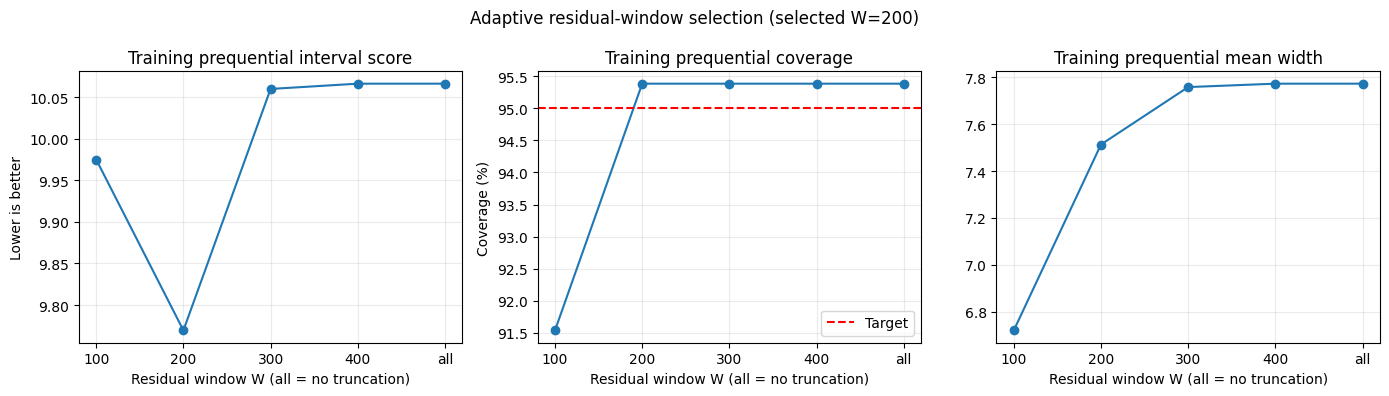

In [6]:
display(out_of_time_result.window_selection)
plot_window_selection(out_of_time_result)
plt.show()


## 最終預測圖

沿用原本五張圖的畫法，但第三、四、五張圖的 residual interval 都來自 out-of-time calibration pool。

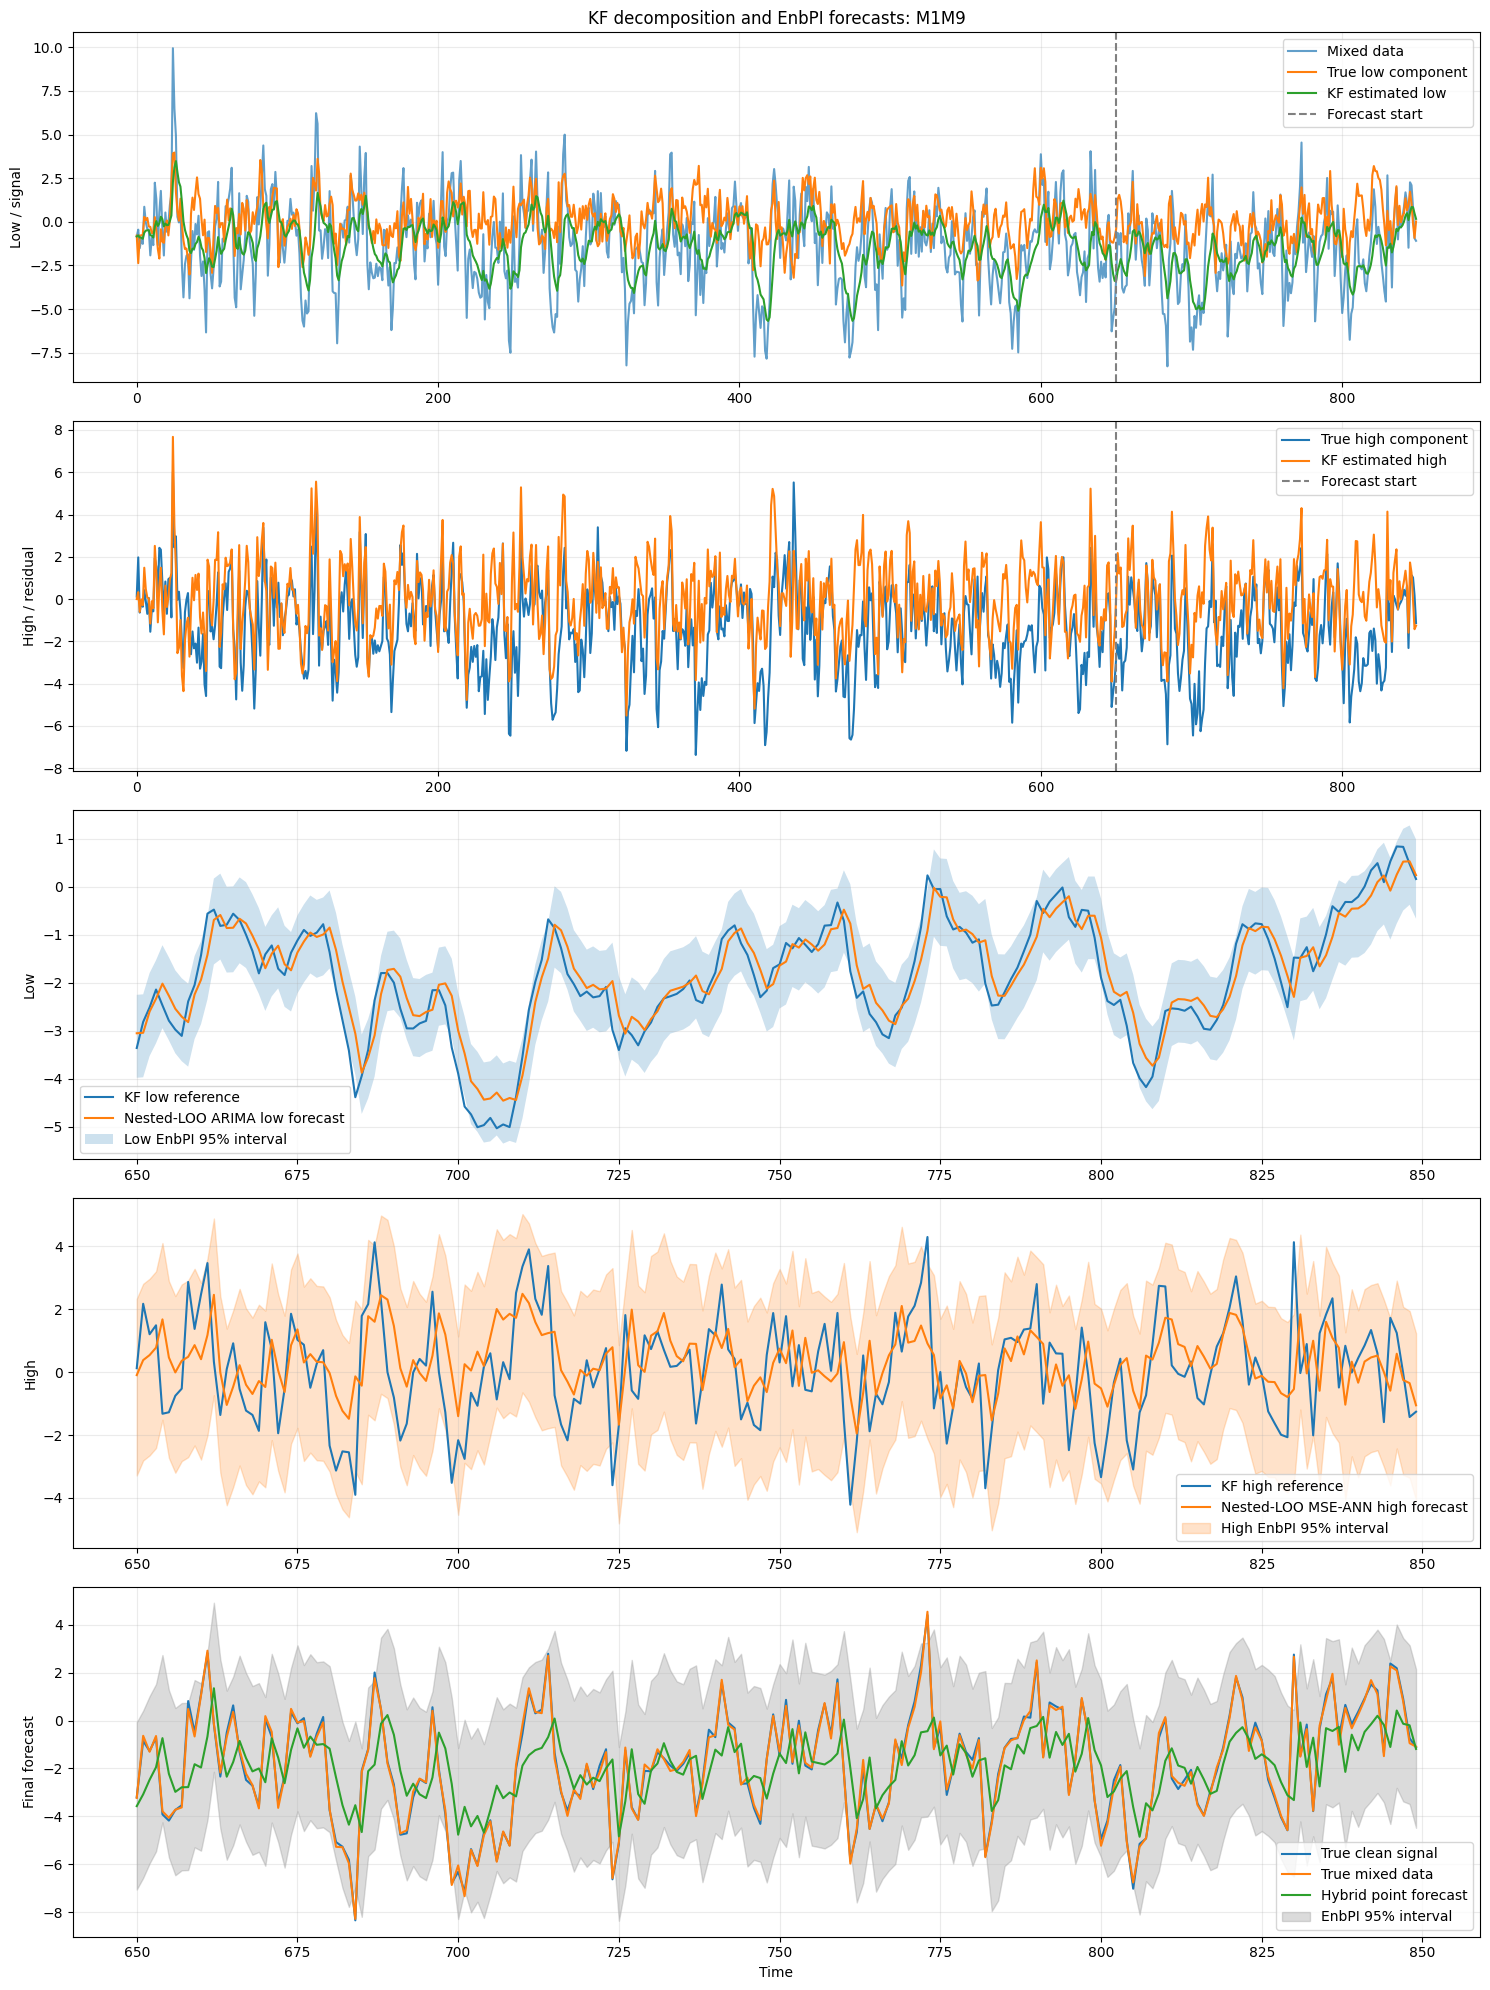

In [7]:
plot_result(result)
plt.show()


## Monte Carlo（選擇性執行）

Out-of-time 版本每一 run 會在多個 fold 重做完整 ARIMA+ANN fitting，因此明顯比舊版慢。先用 3 runs 驗證流程，正式報告再改成 20。

In [8]:
RUN_MONTE_CARLO = True
N_RUNS = 20

if RUN_MONTE_CARLO:
    mc_runs, mc_summary, mc_results = monte_carlo_out_of_time(
        'm1m9',
        n_runs=N_RUNS,
        train_size=train_size,
        horizon=horizon,
        config=config,
        seed=2026,
    )
    display(mc_runs)
    display(mc_summary)


,run,data_seed,mse,rmse,coverage,coverage_percent,mean_width,median_width,low_kf_mse,low_kf_rmse,...,low_true_rmse,low_true_coverage,high_true_mse,high_true_rmse,high_true_coverage,calibration_method,selected_residual_window,crossfit_residual_count,crossfit_fold_count,initial_test_pool_size
0,1,479243620,3.584329,1.893232,0.925,92.5,7.246022,7.223876,0.239174,0.489054,...,1.771869,0.415,4.952296,2.225375,0.810,rolling_origin_block_crossfit,200.0,325.0,4.0,200.0
1,2,454024514,3.634913,1.906545,0.950,95.0,7.267107,7.242415,0.224766,0.474095,...,1.847804,0.345,3.839000,1.959337,0.870,rolling_origin_block_crossfit,400.0,325.0,4.0,325.0
2,3,1818751028,2.651518,1.628348,0.970,97.0,7.188749,7.215723,0.134881,0.367262,...,1.515166,0.470,3.040447,1.743688,0.885,rolling_origin_block_crossfit,300.0,325.0,4.0,300.0
3,4,2288458700,4.197596,2.048803,0.935,93.5,7.770294,7.821318,0.265296,0.515068,...,2.289091,0.360,7.657870,2.767286,0.740,rolling_origin_block_crossfit,100.0,325.0,4.0,100.0
4,5,2115331525,3.746355,1.935550,0.930,93.0,7.167213,7.289195,0.230846,0.480464,...,1.898432,0.410,4.052918,2.013186,0.855,rolling_origin_block_crossfit,100.0,325.0,4.0,100.0
5,6,2666256175,4.250912,2.061774,0.915,91.5,7.087418,7.117959,0.287052,0.535772,...,1.905173,0.330,5.851766,2.419042,0.765,rolling_origin_block_crossfit,100.0,325.0,4.0,100.0
6,7,975381835,3.767855,1.941096,0.905,90.5,7.023268,6.948429,0.198888,0.445968,...,2.004492,0.330,5.149451,2.269240,0.805,rolling_origin_block_crossfit,300.0,325.0,4.0,300.0
7,8,2535166222,3.951836,1.987922,0.955,95.5,7.764496,7.655113,0.227086,0.476535,...,2.086948,0.340,5.737858,2.395383,0.820,rolling_origin_block_crossfit,300.0,325.0,4.0,300.0
8,9,1079577930,4.549516,2.132959,0.940,94.0,8.361840,8.361697,0.283487,0.532435,...,2.509994,0.305,9.301496,3.049835,0.750,rolling_origin_block_crossfit,400.0,325.0,4.0,325.0
9,10,3715024065,3.685782,1.919839,0.935,93.5,7.055412,6.989476,0.229334,0.478889,...,2.023183,0.325,6.310841,2.512139,0.740,rolling_origin_block_crossfit,200.0,325.0,4.0,200.0


,metric,mean,std
0,ann_nonconverged_models,30.000000,0.000000
1,ann_rolling_validation_mse,3.308744,0.492026
2,ann_selected_max_iter_mean,125.000000,0.000000
3,arima_nonconverged_fits,0.000000,0.000000
4,arima_retry_count,0.050000,0.223607
5,coverage,0.938250,0.016645
6,coverage_percent,93.825000,1.664450
7,crossfit_fold_count,4.000000,0.000000
8,crossfit_residual_count,325.000000,0.000000
9,elapsed_seconds,249.198130,29.155068


## Monte Carlo 圖形

這一格只使用上一格已經算好的 `mc_runs` 與 `mc_results`，不會重新執行 Monte Carlo。第一張圖比較各次 run 的 RMSE、coverage、width 與 component RMSE；第二張是 RMSE 最接近中位數之代表性 run 的完整預測圖；第三張顯示每一個 forecast step 跨所有 runs 的 RMSE、coverage 與 interval width。


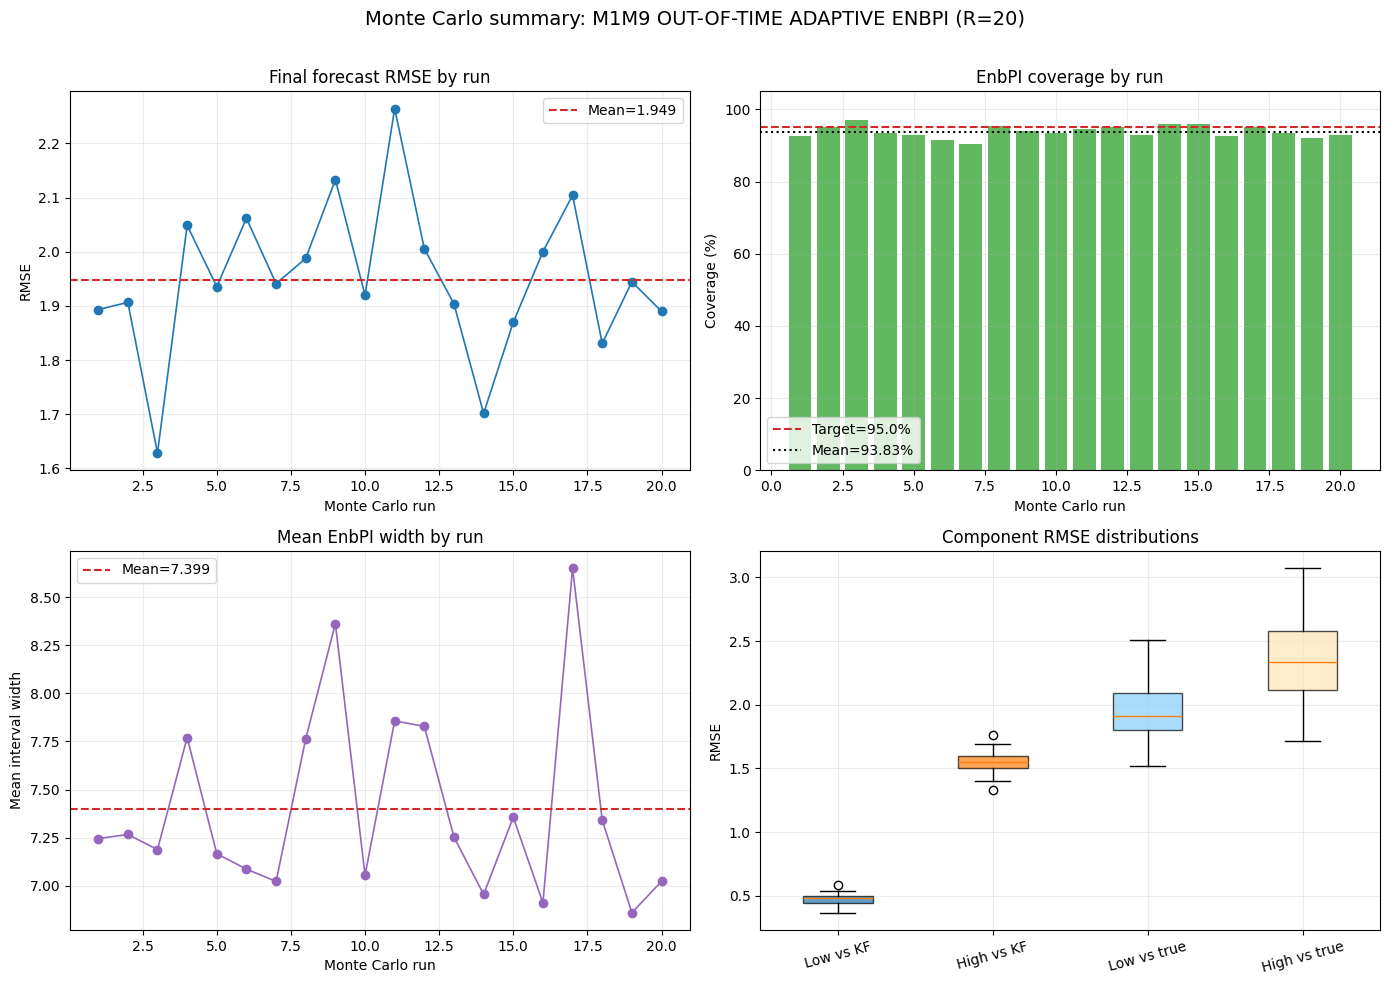

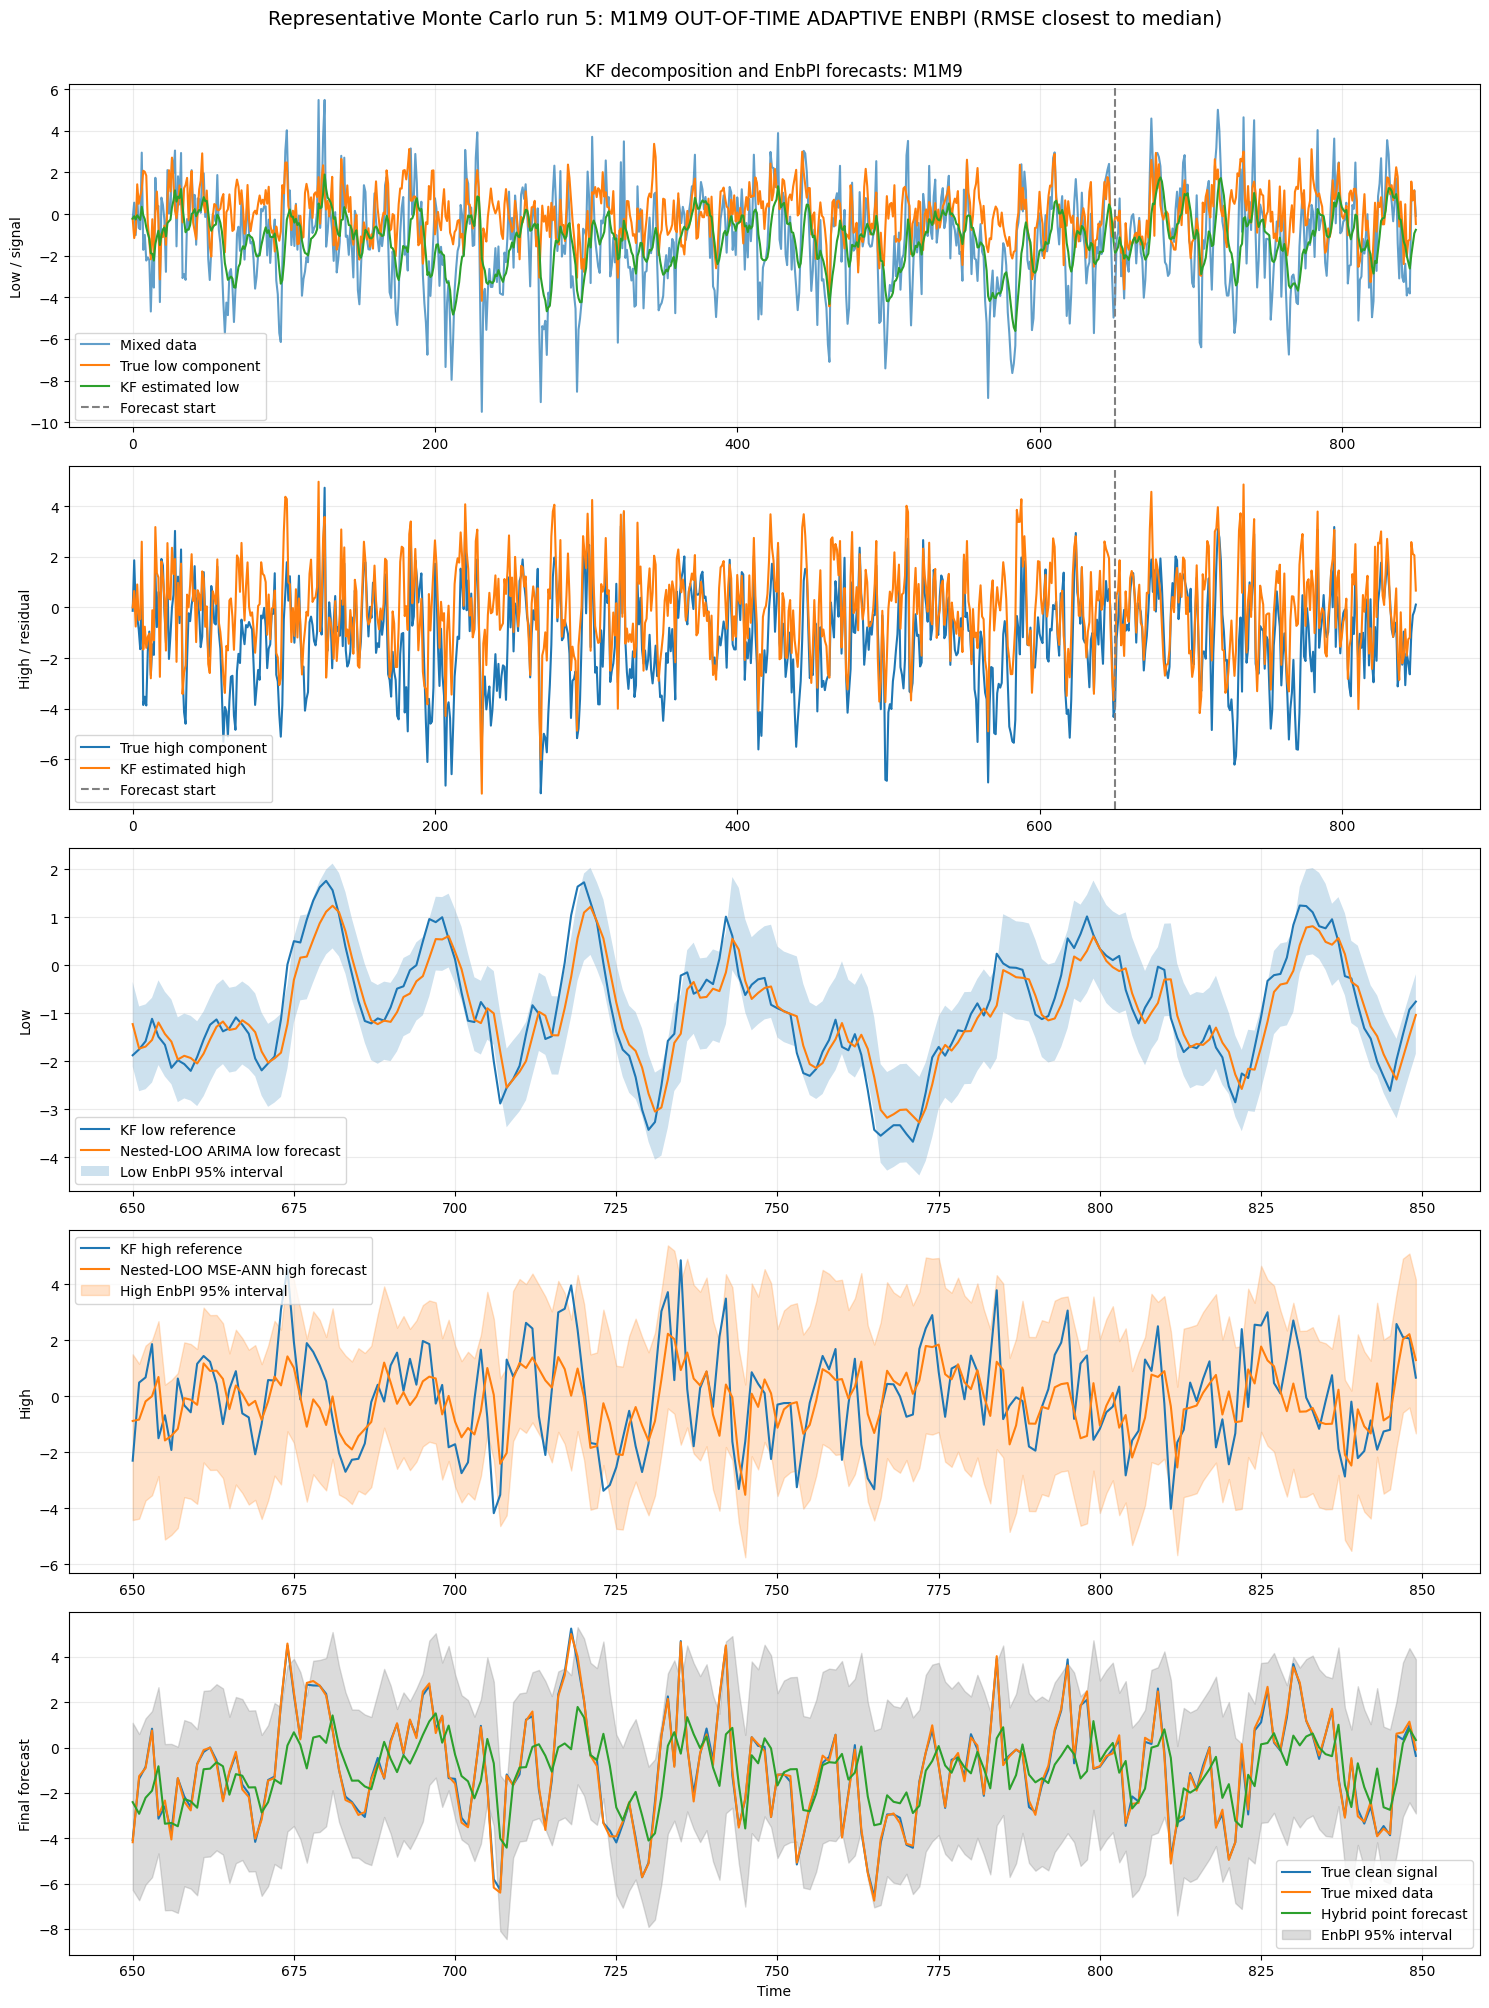

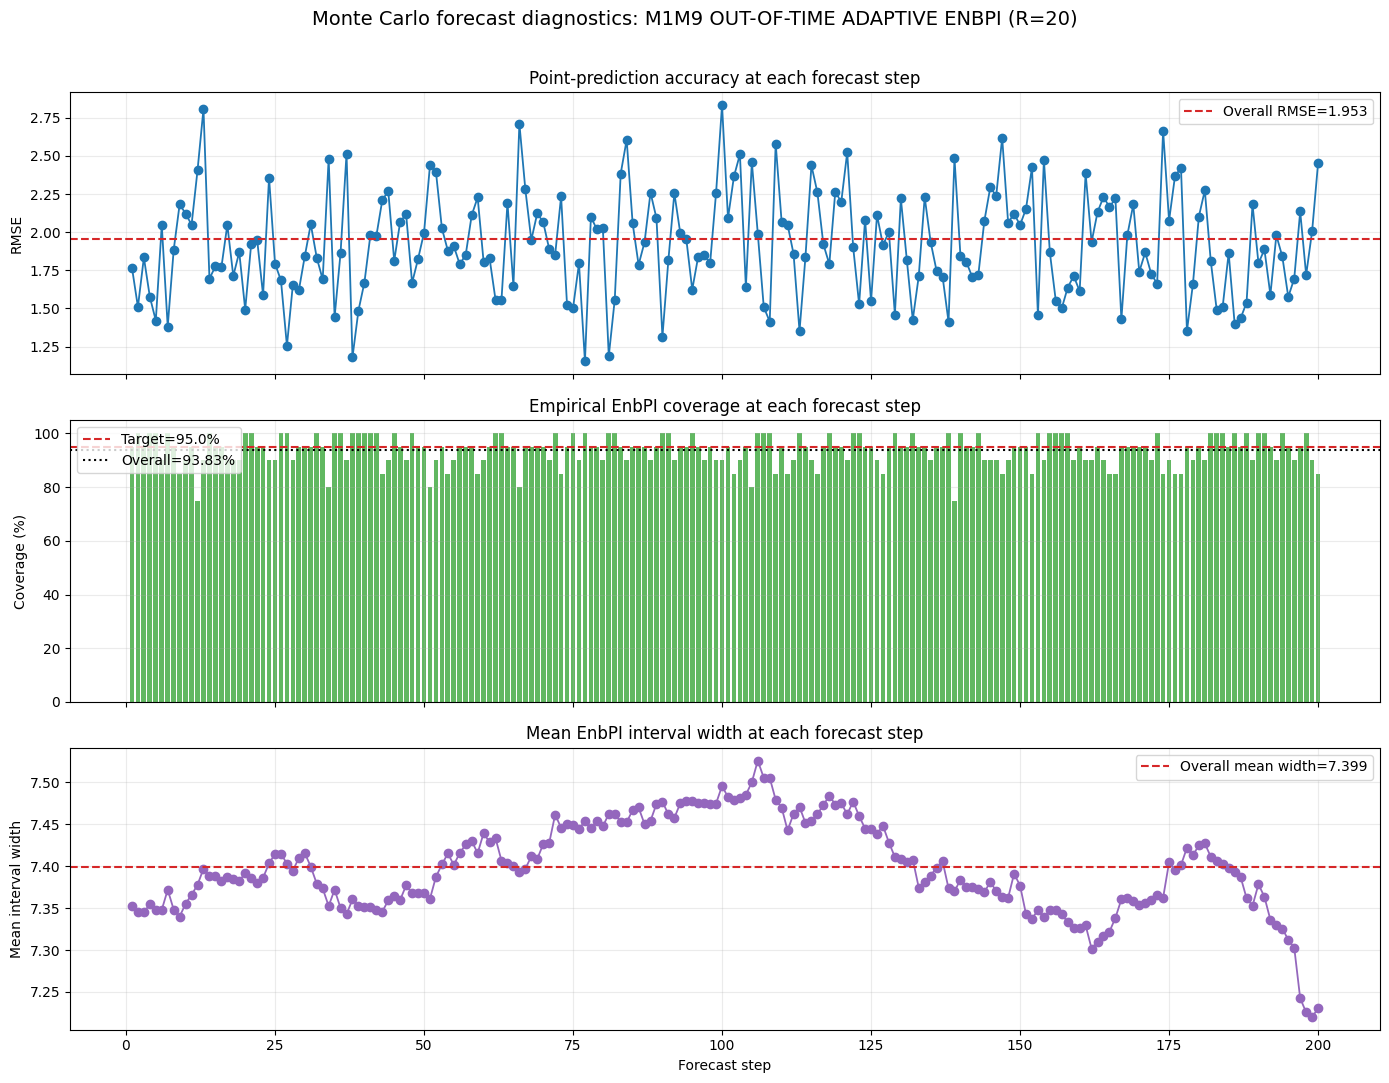

In [9]:
# 只畫現有 Monte Carlo 結果，不重新訓練或重跑模擬
if 'mc_runs' not in globals() or 'mc_results' not in globals():
    raise RuntimeError(
        '目前 kernel 中找不到 mc_runs / mc_results；請確認剛才的 Monte Carlo 結果仍在同一個 kernel。'
    )

from kf_forecasting.models.kf_enbpi import (
    plot_monte_carlo_forecast_diagnostics,
    plot_monte_carlo_summary,
)

# OutOfTime Monte Carlo 儲存的是含 audit trail 的 wrapper；繪圖只需要其中的 forecast。
mc_forecasts = [item.forecast for item in mc_results]

plot_monte_carlo_summary(
    mc_runs,
    model_name='M1M9 out-of-time adaptive EnbPI',
    alpha=config.base.alpha,
)
plot_monte_carlo_forecast_diagnostics(
    mc_runs,
    mc_forecasts,
    model_name='M1M9 out-of-time adaptive EnbPI',
    alpha=config.base.alpha,
)
plt.show()
